In [1]:
import numpy as np
import pandas as np
import matplotlib.pyplot as plt

In [4]:
def loss_function(m, b, points):
    points = np.array(points)
    x = points[:, 0]
    y = points[:, 1]

    y_pred = x * m + b
    total_sum = np.sum(np.power(y_pred - y, 2))

    return total_sum/len(points)

In [5]:
def gradient_descent(m, b, points, learning_rate):
    points = np.array(points)
    x = points[:, 0]
    y = points[:, 1]

    gradient_m = (-2 * np.sum(x * (y - (m * x + b)))) / len(points) #derivative from loss function np.sum(np.power(y_pred - y, 2)) with respect to x
    gradient_b = (-2 * np.sum(y - (m * x + b))) / len(points) #same derivative but with respect to b

    m_new = m - learning_rate * gradient_m
    b_new = b - learning_rate * gradient_b

    return m_new, b_new

In [7]:
def train(learning_rate, points, epochs):
    m, b = 0, 0

    for i in range(epochs):
        m, b = gradient_descent(m, b, points, learning_rate)
        if i % 100 == 0:
            print(f"epoch {i} — Current loss (MSE): {loss_function(m, b, points)}")

    return m, b

In [9]:
import numpy as np

np.random.seed(42)
x = np.linspace(0, 10, 50)
true_m, true_b = 3, 5
noise = np.random.normal(0, 2, size=x.shape)
y = true_m * x + true_b + noise

points = list(zip(x, y))
m, b = train(learning_rate=0.01, points=points, epochs=2000)
print(f"Learned: y = {m:.3f}x + {b:.3f}  (true: y = {true_m}x + {true_b})")

epoch 0 — Current loss (MSE): 52.258755586966025
epoch 100 — Current loss (MSE): 5.260508921377985
epoch 200 — Current loss (MSE): 4.014085756623723
epoch 300 — Current loss (MSE): 3.5603242680763234
epoch 400 — Current loss (MSE): 3.395131984820465
epoch 500 — Current loss (MSE): 3.334993583620659
epoch 600 — Current loss (MSE): 3.313100143881303
epoch 700 — Current loss (MSE): 3.305129817200548
epoch 800 — Current loss (MSE): 3.302228212511917
epoch 900 — Current loss (MSE): 3.3011718806818298
epoch 1000 — Current loss (MSE): 3.300787322116829
epoch 1100 — Current loss (MSE): 3.30064732322093
epoch 1200 — Current loss (MSE): 3.300596356495348
epoch 1300 — Current loss (MSE): 3.3005778020124716
epoch 1400 — Current loss (MSE): 3.3005710472360783
epoch 1500 — Current loss (MSE): 3.3005685881535793
epoch 1600 — Current loss (MSE): 3.300567692922355
epoch 1700 — Current loss (MSE): 3.3005673670126123
epoch 1800 — Current loss (MSE): 3.300567248364873
epoch 1900 — Current loss (MSE): 3.30

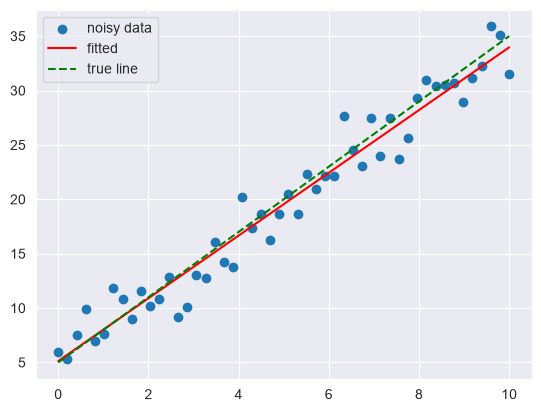

In [10]:
import matplotlib.pyplot as plt
plt.scatter(x, y, label='noisy data')
plt.plot(x, m*x+b, color='red', label='fitted')
plt.plot(x, true_m*x+true_b, color='green', linestyle='--', label='true line')
plt.legend()
plt.show()

In [11]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
x = X.flatten()

points = list(zip(x, y))
m, b = train(learning_rate=0.01, points=points, epochs=2000)

from sklearn.linear_model import LinearRegression
sk_lr = LinearRegression().fit(X, y)
print(f"Yours:   m={m:.3f}, b={b:.3f}")
print(f"sklearn: m={sk_lr.coef_[0]:.3f}, b={sk_lr.intercept_:.3f}")

epoch 0 — Current loss (MSE): 1648.5866157083965
epoch 100 — Current loss (MSE): 136.88158457621353
epoch 200 — Current loss (MSE): 80.47029517657806
epoch 300 — Current loss (MSE): 78.15702217479947
epoch 400 — Current loss (MSE): 78.058675951629
epoch 500 — Current loss (MSE): 78.0544417838917
epoch 600 — Current loss (MSE): 78.05425870736055
epoch 700 — Current loss (MSE): 78.05425078019908
epoch 800 — Current loss (MSE): 78.05425043679178
epoch 900 — Current loss (MSE): 78.0542504219129
epoch 1000 — Current loss (MSE): 78.05425042126821
epoch 1100 — Current loss (MSE): 78.05425042124028
epoch 1200 — Current loss (MSE): 78.05425042123906
epoch 1300 — Current loss (MSE): 78.05425042123899
epoch 1400 — Current loss (MSE): 78.054250421239
epoch 1500 — Current loss (MSE): 78.05425042123902
epoch 1600 — Current loss (MSE): 78.05425042123899
epoch 1700 — Current loss (MSE): 78.05425042123902
epoch 1800 — Current loss (MSE): 78.054250421239
epoch 1900 — Current loss (MSE): 78.054250421239


In [15]:
def linear_regression_closed_form(points):
    points = np.array(points)
    x = points[:, 0]
    y = points[:, 1]

    X = np.c_[np.ones(len(x)), x]   # bias column + x column

    XtX_inv = np.linalg.inv(X.T @ X)
    Xty = X.T @ y

    w = XtX_inv @ Xty
    return w[1], w[0]   # m, b

In [16]:
def predict(x_new, m, b):
    return m * x_new + b

In [20]:
np.random.seed(42)
x = np.linspace(0, 10, 50)
true_m, true_b = 3, 5
noise = np.random.normal(0, 2, size=x.shape)
y = true_m * x + true_b + noise
points = list(zip(x, y))

In [21]:
X_sklearn = x.reshape(-1, 1)
sk_lr = LinearRegression().fit(X_sklearn, y)
print(f"sklearn:          m={sk_lr.coef_[0]:.3f}, b={sk_lr.intercept_:.3f}")

m_gd, b_gd = train(learning_rate=0.01, points=points, epochs=2000)
print(f"Gradient descent: m={m_gd:.3f}, b={b_gd:.3f}")

m_cf, b_cf = linear_regression_closed_form(points)
print(f"Closed form:      m={m_cf:.3f}, b={b_cf:.3f}")

sklearn:          m=2.884, b=5.129
epoch 0 — Current loss (MSE): 52.258755586966025
epoch 100 — Current loss (MSE): 5.260508921377985
epoch 200 — Current loss (MSE): 4.014085756623723
epoch 300 — Current loss (MSE): 3.5603242680763234
epoch 400 — Current loss (MSE): 3.395131984820465
epoch 500 — Current loss (MSE): 3.334993583620659
epoch 600 — Current loss (MSE): 3.313100143881303
epoch 700 — Current loss (MSE): 3.305129817200548
epoch 800 — Current loss (MSE): 3.302228212511917
epoch 900 — Current loss (MSE): 3.3011718806818298
epoch 1000 — Current loss (MSE): 3.300787322116829
epoch 1100 — Current loss (MSE): 3.30064732322093
epoch 1200 — Current loss (MSE): 3.300596356495348
epoch 1300 — Current loss (MSE): 3.3005778020124716
epoch 1400 — Current loss (MSE): 3.3005710472360783
epoch 1500 — Current loss (MSE): 3.3005685881535793
epoch 1600 — Current loss (MSE): 3.300567692922355
epoch 1700 — Current loss (MSE): 3.3005673670126123
epoch 1800 — Current loss (MSE): 3.300567248364873
ep

In [22]:
x_new = 7.5

sk_guess = sk_lr.predict([[x_new]])[0]
gd_guess = predict(x_new, m_gd, b_gd)
cf_guess = predict(x_new, m_cf, b_cf)

print(f"sklearn guess:          {sk_guess:.3f}")
print(f"Gradient descent guess: {gd_guess:.3f}")
print(f"Closed form guess:      {cf_guess:.3f}")

sklearn guess:          26.759
Gradient descent guess: 26.759
Closed form guess:      26.759
